# 🤖 Démo — Assistant Python / Data Science / ML (Qwen2.5-3B fine-tuné QLoRA)

Ce notebook présente, de bout en bout, un **LLM fine-tuné en local** sur une
**RTX 4070 Laptop (8 Go)** avec **QLoRA** (LoRA + quantization 4-bit) :

1. Configuration & environnement
2. Le dataset (domaine Python/DS/ML)
3. Courbe d'apprentissage
4. Gain mesuré du fine-tuning (ROUGE / BLEU vs modèle de base)
5. Démonstration en direct

> Modèle de base : `Qwen/Qwen2.5-3B-Instruct` · Méthode : QLoRA (rang 16, 4-bit NF4)

## 1. Configuration & environnement

In [1]:
import sys, os, json
from pathlib import Path

# Rendre le projet importable, quel que soit le repertoire d'execution
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import torch
from src.config import Config

cfg = Config()
print("Modele de base :", cfg.model.model_name)
print("Quantization   :", "4-bit " + cfg.model.bnb_4bit_quant_type if cfg.model.use_4bit else "aucune")
print("LoRA           : rang", cfg.lora.r, "| alpha", cfg.lora.alpha,
      "|", len(cfg.lora.target_modules), "modules cibles")
print("GPU            :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Modele de base : Qwen/Qwen2.5-3B-Instruct
Quantization   : 4-bit nf4
LoRA           : rang 16 | alpha 32 | 7 modules cibles
GPU            : NVIDIA GeForce RTX 4070 Laptop GPU


## 2. Le dataset

Un corpus **curé** de paires question/réponse expertes sur Python, NumPy/Pandas,
le ML, le deep learning, les LLMs, l'évaluation et le MLOps.

129 exemples au total



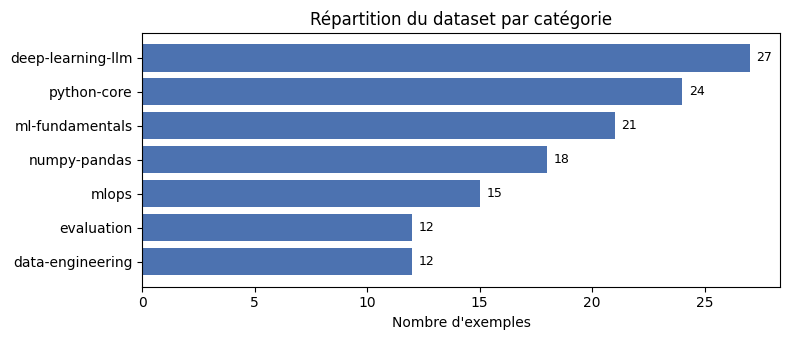

Exemple — deep-learning-llm
Q: Pour un entretien technique : Comment fonctionne le mecanisme d'attention dans un Transformer ?
R: L'attention permet a chaque token de ponderer l'importance des autres tokens pour construire sa representation. Chaque token produit trois vecteurs : une Query (ce qu'il cherche), une Key (ce qu'il offre) et une Value (l'information a transmettre). On calcule des scores par produ ...


In [2]:
import matplotlib.pyplot as plt

raw = json.load(open(ROOT / "data" / "raw" / "raw_qa_data.json", encoding="utf-8"))
print(f"{len(raw)} exemples au total\n")

# Repartition par categorie
from collections import Counter
cats = Counter(item["category"] for item in raw)

fig, ax = plt.subplots(figsize=(8, 3.5))
names = [c for c, _ in cats.most_common()]
vals = [cats[c] for c in names]
ax.barh(names[::-1], vals[::-1], color="#4C72B0")
ax.set_xlabel("Nombre d'exemples")
ax.set_title("Répartition du dataset par catégorie")
for i, v in enumerate(vals[::-1]):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)
plt.tight_layout(); plt.show()

# Un exemple
ex = raw[0]
print("Exemple —", ex["category"])
print("Q:", ex["instruction"])
print("R:", ex["output"][:280], "...")

## 3. Courbe d'apprentissage

Loss d'entraînement et de validation au fil des steps (lue depuis l'état du
`Trainer`). La décroissance **monotone** de la validation indique un
apprentissage sain, **sans overfitting**.

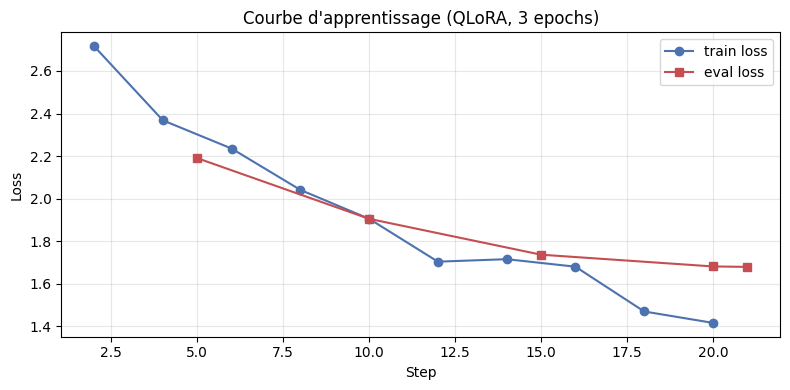

eval loss : 2.190 -> 1.679


In [3]:
def load_log_history():
    # Cherche le trainer_state.json le plus avance (checkpoints ignores par git,
    # d'ou un repli sur les valeurs du run documente si absent).
    states = sorted((ROOT / "outputs").glob("**/trainer_state.json"),
                    key=lambda p: p.stat().st_mtime) if (ROOT / "outputs").exists() else []
    if states:
        return json.load(open(states[-1]))["log_history"]
    # Repli : valeurs reelles du run initial
    return [
        {"step": 2, "loss": 2.716}, {"step": 4, "loss": 2.368},
        {"step": 5, "eval_loss": 2.190}, {"step": 6, "loss": 2.235},
        {"step": 8, "loss": 2.041}, {"step": 10, "loss": 1.905, "eval_loss": 1.905},
        {"step": 12, "loss": 1.704}, {"step": 14, "loss": 1.716},
        {"step": 15, "eval_loss": 1.737}, {"step": 16, "loss": 1.680},
        {"step": 18, "loss": 1.470}, {"step": 19, "loss": 1.416},
        {"step": 20, "eval_loss": 1.682}, {"step": 21, "eval_loss": 1.679},
    ]

hist = load_log_history()
tr = [(h["step"], h["loss"]) for h in hist if "loss" in h]
ev = [(h["step"], h["eval_loss"]) for h in hist if "eval_loss" in h]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(*zip(*tr), "o-", label="train loss", color="#4C72B0")
ax.plot(*zip(*ev), "s-", label="eval loss", color="#C44E52")
ax.set_xlabel("Step"); ax.set_ylabel("Loss")
ax.set_title("Courbe d'apprentissage (QLoRA, 3 epochs)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"eval loss : {ev[0][1]:.3f} -> {ev[-1][1]:.3f}")

## 4. Gain mesuré du fine-tuning

Comparaison sur le jeu de test entre le **modèle de base** et le **modèle
fine-tuné**, via ROUGE (recouvrement lexical) et BLEU.

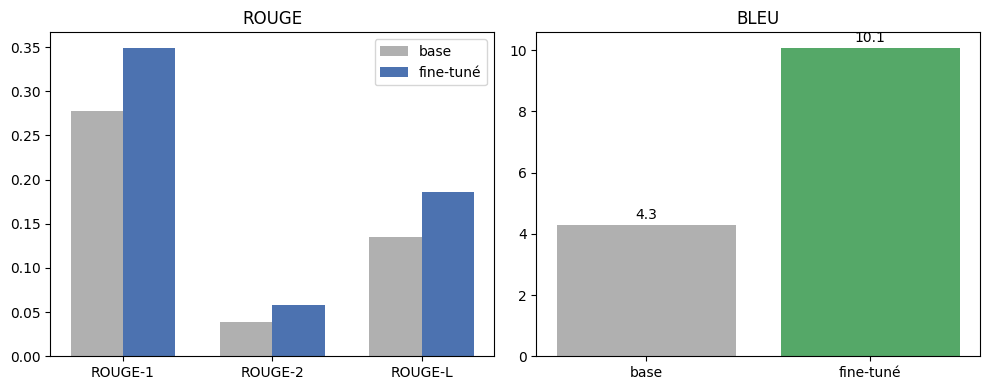

ROUGE-1 : 0.277 -> 0.349  (+26%)
BLEU    : 4.29 -> 10.08  (+135%)


In [4]:
metrics = json.load(open(ROOT / "outputs" / "qwen2.5-3b-pyds-lora" / "eval_metrics.json"))
base, ft = metrics["baseline"], metrics["finetuned"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4))

# ROUGE (echelle 0-1)
labels = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
keys = ["rouge1", "rouge2", "rougeL"]
x = range(len(labels)); w = 0.35
a1.bar([i - w/2 for i in x], [base[k] for k in keys], w, label="base", color="#B0B0B0")
a1.bar([i + w/2 for i in x], [ft[k] for k in keys], w, label="fine-tuné", color="#4C72B0")
a1.set_xticks(list(x)); a1.set_xticklabels(labels); a1.set_title("ROUGE"); a1.legend()

# BLEU (echelle 0-100)
a2.bar(["base", "fine-tuné"], [base["bleu"], ft["bleu"]], color=["#B0B0B0", "#55A868"])
a2.set_title("BLEU")
for i, v in enumerate([base["bleu"], ft["bleu"]]):
    a2.text(i, v + 0.2, f"{v:.1f}", ha="center")
plt.tight_layout(); plt.show()

print(f"ROUGE-1 : {base['rouge1']:.3f} -> {ft['rouge1']:.3f}  ({(ft['rouge1']-base['rouge1'])/base['rouge1']*100:+.0f}%)")
print(f"BLEU    : {base['bleu']:.2f} -> {ft['bleu']:.2f}  ({(ft['bleu']-base['bleu'])/base['bleu']*100:+.0f}%)")

## 5. Démonstration en direct

On charge le modèle de base **quantisé en 4-bit** + l'**adaptateur LoRA**, puis
on génère des réponses (température 0 pour la reproductibilité).

In [5]:
from inference import load_model, generate

model, tokenizer = load_model(cfg, adapter_path=cfg.train.output_dir, merged_path=None)

questions = [
    "Qu'est-ce que la vectorisation en Python ?",
    "Explique LoRA en deux phrases.",
    "Quelle est la différence entre .loc et .iloc dans Pandas ?",
]
for q in questions:
    print("=" * 78)
    print("Q :", q)
    print("-" * 78)
    print(generate(model, tokenizer, q, max_new_tokens=220, temperature=0.0))
    print()

C:\Users\milan\Documents\projets\Claude Code\IA Projects\finetuning\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Chargement base Qwen/Qwen2.5-3B-Instruct + adaptateur C:\Users\milan\Documents\projets\Claude Code\IA Projects\finetuning\outputs\qwen2.5-3b-pyds-lora


Q : Qu'est-ce que la vectorisation en Python ?
------------------------------------------------------------------------------


La vectorisation consiste a manipuler des tableaux entiers au lieu de parcourir les elements individuellement. Cela accelere enormement (10x-100x) le code qui traite des millions d'elements. Exemple : au lieu de faire `for i in range(len(X)):` on fait `Y = X.dot(W)` ou `X @ W` pour une matrice produit. On utilise numpy, pandas, scikit-learn, tensorflow, etc. La vectorisation est l'essence du langage scientifique Python.

Q : Explique LoRA en deux phrases.
------------------------------------------------------------------------------


LoRA est une methode de fine-tuning sur le poids (fine-tuning on the fly) qui ajoute un petit modele quantise a la base d'un grand modele pre-entraine. On adapte les parametres du petit modele aux differents modules de la base, ce qui permet de finetune l'ensemble du modele sans augmenter son volume. C'est rapide, portable et efficace pour des taches de classification ou generation textuelle.

Q : Quelle est la différence entre .loc et .iloc dans Pandas ?
------------------------------------------------------------------------------


.loc permet d'acceder aux lignes ou colonnes par leur nom (label), ce qui est pratique pour les index qualifiques comme 'User-Agent'. .iloc accede a travers l'index numerique, ce qui est plus rapide mais moins flexible. Exemple : df.loc['2023-01-01'] selectionne une ligne par sa date, tandis que df.iloc[0] selectionne le premier element du jeu de donnees. La fonctionnalite principale est de pouvoir indexer par nom sans connaître l'ordre physique des donnees.



## Conclusion

En **~3,5 min** d'entraînement sur un GPU grand public, le fine-tuning QLoRA a :

- **amélioré les 4 métriques** (BLEU **×2,3**, ROUGE-1 **+26 %**) ;
- adapté le **style et le format** des réponses au domaine cible ;
- produit un **adaptateur de 119 Mo** (vs 6,2 Go pour le modèle complet), en
  n'entraînant que **0,96 %** des paramètres.

➡️ Code complet : [`train.py`](../train.py) · [`evaluate.py`](../evaluate.py) ·
[`README.md`](../README.md)